# Twitter Sentiment Analysis

## Цель проекта
Построить модель для binary text classification на несбалансированном наборе твитов и сравнить нейросетевой и классические подходы.

## Что важно в этой задаче
Положительный класс встречается редко, поэтому `accuracy` почти бесполезна как основная метрика. Ниже я ориентируюсь на `precision`, `recall`, `f1` и `ROC-AUC`.

## План эксперимента
1. Очистка и быстрый анализ данных.
2. Baseline на замороженных `DistilBERT`-эмбеддингах + `GRU`.
3. Сравнение с более простыми текстовыми baseline-моделями.
4. Проверка идеи с `Focal Loss` для борьбы с дисбалансом.


In [6]:
import os
import io
import re
import zipfile
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from tqdm import tqdm
from transformers import AutoModel, AutoTokenizer

warnings.filterwarnings("ignore")
torch.manual_seed(1)
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

## Загрузка данных
Ноутбук ожидает `train.csv` и `test.csv` локально. Если файлов нет, он пытается скачать и распаковать архив по ссылке Kaggle API.


In [7]:
DATA_DIR = Path("data")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
DATASET_URL = (
    "https://www.kaggle.com/api/v1/datasets/download/"
    "arkhoshghalb/twitter-sentiment-analysis-hatred-speech"
)

def download_and_unpack_dataset(api_url, extract_dir):
    extract_dir = Path(extract_dir)
    extract_dir.mkdir(parents=True, exist_ok=True)

    if TRAIN_PATH.exists() and TEST_PATH.exists():
        print(f"Датасет уже доступен: {extract_dir}")
        return

    response = requests.get(api_url, timeout=120)
    response.raise_for_status()

    archive = zipfile.ZipFile(io.BytesIO(response.content))
    archive.extractall(extract_dir)
    print(f"Распаковано в: {extract_dir}")

download_and_unpack_dataset(DATASET_URL, DATA_DIR)


Датасет уже доступен: data


In [8]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

train.shape, test.shape

((31962, 3), (17197, 2))

## Первичный анализ
Смотрю на структуру датасета и быстро проверяю, какие данные реально доступны.


In [9]:
train.tail()

,id,label,tweet
31957,31958,0,ate @user isz that youuu?ðððððð...
31958,31959,0,to see nina turner on the airwaves trying to...
31959,31960,0,listening to sad songs on a monday morning otw...
31960,31961,1,"@user #sikh #temple vandalised in in #calgary,..."
31961,31962,0,thank you @user for you follow


В `test.csv` нет целевой метки, поэтому он подходит только для финального inference. Для сравнения моделей в ноутбуке использую только размеченный `train.csv`.


In [10]:
test.tail()

,id,tweet
17192,49155,thought factory: left-right polarisation! #tru...
17193,49156,feeling like a mermaid ð #hairflip #neverre...
17194,49157,#hillary #campaigned today in #ohio((omg)) &am...
17195,49158,"happy, at work conference: right mindset leads..."
17196,49159,"my song ""so glad"" free download! #shoegaze ..."


In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


Классы распределены неравномерно: большинство твитов относятся к негативному классу `0`. Это сразу задаёт требования к метрикам и стратегии обучения.


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'label'}>]], dtype=object)

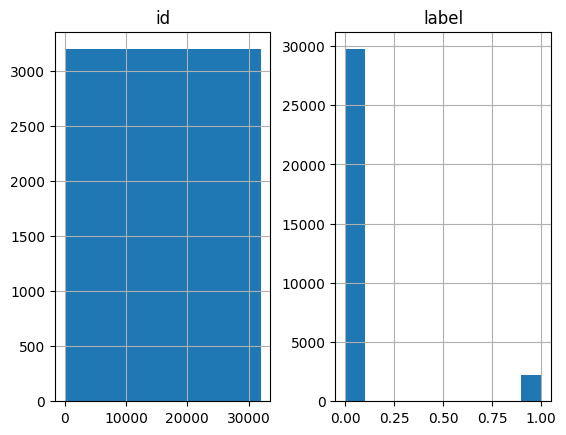

In [12]:
train.hist()

Доля мажоритарного класса близка к `93%`, поэтому даже очень слабый классификатор может показать формально высокую `accuracy`.


In [13]:
(train['label'] == 0).sum() / len(train['label'])

np.float64(0.9298542018647143)

Перед токенизацией полезно посмотреть, сколько в данных шума: спецсимволов, упоминаний пользователей, ссылок и мусорных токенов.


In [14]:
unique_chars = {char for sentence in train['tweet'].values
                for char in sentence}

print(unique_chars)

{'\x9b', 'b', 'c', '\x9a', '¾', 'Ù', '}', '@', 'á', '(', '\x9e', 'x', 'Ë', 'g', ']', '×', '$', 'ï', '\x96', ' ', '\x85', 'l', '\x8c', '\x95', '\x82', '\x94', 'y', 'r', 'ª', 'å', 'k', '+', '¢', '\x9c', '¼', '&', '\x8f', 'Ø', 'd', '%', '\x89', '³', ')', '!', 'j', '¯', '»', '"', '±', '^', '¤', 'w', '´', 'ó', '7', 't', 'ë', 'è', '\x88', '\x8a', 'n', '[', '\x92', '=', '\x93', '\x99', '8', ';', '©', '®', 'ä', 'Ñ', 'f', '.', 'p', '¥', '1', '\x8d', 'í', '4', '3', '¬', '6', '·', 'h', 'æ', 'Ã', 'ã', '¡', '§', '\x90', 'z', '\x81', 'Å', '|', '\x9f', '½', '-', '¶', '²', '°', '/', 's', 'â', 'Ä', '#', '\x80', 'Ï', 'ê', "'", '5', '\x83', '0', 'Ð', '«', 'é', '`', 'v', 'q', '\xa0', '_', '\x86', '¸', '\x91', 'à', 'î', 'ì', '?', 'ò', 'e', 'ç', 'º', '\x8b', 'Â', '¦', '\x84', '\xad', '¹', 'ñ', 'i', 'a', '\x8e', 'u', '£', '\x87', 'µ', '\x98', 'm', ',', 'Î', '*', '\\', '9', '\x9d', 'o', 'ð', '¨', '\x97', ':', '2', '~', '{', '¿'}


Очищаю тексты минимально:
- удаляю placeholder `@user`;
- убираю ссылки и лишние символы;
- привожу текст к нижнему регистру;
- нормализую пробелы;
- отбрасываю пустые строки после очистки.


In [15]:
def preprocess_tweet(text):
    text = text.lower()
    text = text.replace("@user", " ")
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9# ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text or None

In [ ]:
train["clean_tweet"] = train["tweet"].transform(preprocess_tweet)
train["clean_tweet"].sample(15, random_state=1)

266      i ll probably be 30 by the time comes back hom...
20460    just finished recoding my audition for abc dic...
18133       this will be dustin s bihday present bihday dj
15417    this is my do i really have to go to work face...
3077                                    eat the all #muslm
2863     still can t believe what happened in pulse nig...
21911                     prom amp graduation is next week
31665    #antisemitism kills in 2017 remember no one is...
22891    you have to learn that you re not gonna get an...
11233    what happened in orlando last night i m lost f...
18650           sunny summer days #flowers #fashionblogger
832          we the people are failing our fellow citizens
21691       essential reading by someone you should follow
30703       #model i love u take with u all the time in ur
22201    dc has already posted having a vigil tonight i...
Name: clean_tweet, dtype: object

После очистки удаляю пустые наблюдения и работаю уже с валидным текстовым корпусом.


In [17]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           31962 non-null  int64 
 1   label        31962 non-null  int64 
 2   tweet        31962 non-null  object
 3   clean_tweet  31960 non-null  object
dtypes: int64(2), object(2)
memory usage: 998.9+ KB


In [18]:
train.dropna(inplace=True)
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31960 entries, 0 to 31961
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           31960 non-null  int64 
 1   label        31960 non-null  int64 
 2   tweet        31960 non-null  object
 3   clean_tweet  31960 non-null  object
dtypes: int64(2), object(2)
memory usage: 1.2+ MB


## Конфигурация эксперимента
Отдельно фиксирую устройство, длину последовательности и решающий порог для редкого положительного класса.


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64 if device.type == "cuda" else 16
max_length = 64
classification_threshold = 0.4

print("Device:", device)
print("Batch size:", batch_size)
print("Max length:", max_length)
print("Threshold:", classification_threshold)


Device: cuda
Batch size: 64
Max length: 64
Threshold: 0.4


## Baseline: DistilBERT embeddings + GRU


В качестве основного baseline использую компромиссный вариант:
- беру pretrained `DistilBERT` как источник эмбеддингов;
- не fine-tune-ю encoder, а замораживаю его;
- обучаю только последовательностную голову на `GRU`.

Такой вариант дешевле полного fine-tuning и при этом заметно сильнее простых bag-of-words baseline-решений.


Для англоязычных твитов достаточно стандартной модели `distilbert-base-uncased`: она компактнее BERT-base и хорошо подходит для быстрого эксперимента.


In [21]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
token_model = AutoModel.from_pretrained(model_name).to(device)
token_model.eval()

for parameter in token_model.parameters():
    parameter.requires_grad = False


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
texts = train["clean_tweet"].to_list()
labels = train["label"].astype(np.float32).values


Токенизирую твиты и сохраняю `input_ids` вместе с `attention_mask`.


In [23]:
enc = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=max_length,
    return_tensors="pt",
    add_special_tokens=True,
)

In [24]:
X = [*zip(enc['input_ids'], enc['attention_mask'])]

Выделяю выборку со стратификацией, чтобы положительный класс присутствовал и в train, и в test.


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, labels,
                                                    test_size=0.15,
                                                    stratify=labels,
                                                    random_state=1)
y_train = torch.tensor(y_train).int()
y_test = torch.tensor(y_test).int()

Здесь удобнее использовать собственный `Dataset`, потому что для каждого примера нужно хранить пару тензоров: `input_ids` и `attention_mask`.


In [26]:
class CustomDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], torch.tensor(self.y[idx], dtype=torch.float32)


Для обучения использую `WeightedRandomSampler`, чтобы чаще показывать модели редкий класс без жёсткого дублирования датасета.


In [27]:
class_counts = torch.bincount(y_train)

print(f'Трен. метки: {class_counts}\n'
      f'Тест. метки: {torch.bincount(y_test)}')

Трен. метки: tensor([25260,  1906])
Тест. метки: tensor([4458,  336])


In [28]:
torch.manual_seed(1)

batch_size = 32
num_workers = 0

class_weights = 1.0 / class_counts
sample_weights = class_weights[y_train]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

train_dt = CustomDataset(X_train, y_train)
test_dt = CustomDataset(X_test, y_test)

train_dl = DataLoader(
    train_dt,
    batch_size=batch_size,
    sampler=sampler,
    num_workers=num_workers
)
test_dl = DataLoader(
    test_dt,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)

Проверка, что все получилось:

In [29]:
next(iter(train_dl))

[[tensor([[ 101, 2204, 2851,  ...,    0,    0,    0],
          [ 101, 2025, 2035,  ...,    0,    0,    0],
          [ 101, 2074, 4851,  ...,    0,    0,    0],
          ...,
          [ 101, 2995, 2074,  ...,    0,    0,    0],
          [ 101, 9805, 2361,  ...,    0,    0,    0],
          [ 101, 2058, 7568,  ...,    0,    0,    0]]),
  tensor([[1, 1, 1,  ..., 0, 0, 0],
          [1, 1, 1,  ..., 0, 0, 0],
          [1, 1, 1,  ..., 0, 0, 0],
          ...,
          [1, 1, 1,  ..., 0, 0, 0],
          [1, 1, 1,  ..., 0, 0, 0],
          [1, 1, 1,  ..., 0, 0, 0]])],
 tensor([0., 0., 1., 0., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1.,
         1., 0., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 1., 1.])]

In [30]:
class BertRNN(nn.Module):
    def __init__(self, embed_dim, hidden_size, output_size=1, dropout=0.4):
        super().__init__()
        self.rnn = nn.GRU(
            embed_dim,
            hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout,
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, output_size),
        )

    def forward(self, x):
        input_ids = x[0].to(device)
        attention_mask = x[1].to(device)

        with torch.no_grad():
            embeddings = token_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )

        output, hidden = self.rnn(embeddings.last_hidden_state)
        features = torch.cat((hidden[-2], hidden[-1]), dim=1)
        logits = self.classifier(features).squeeze(1)
        return logits


In [ ]:
embed_dim = token_model.config.hidden_size
hidden_size = 256

model = BertRNN(embed_dim, hidden_size).to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)

Из-за дисбаланса беру порог `0.4`, а не `0.5`. Это не универсальное правило, а рабочая эвристика для данного эксперимента.

Важно: в этом ноутбуке threshold **не подбирается** по validation-выборке, а задаётся вручную. В production-сценарии его стоило бы подбирать отдельно на validation, например по максимуму `f1` или под нужный баланс `precision/recall`.


In [ ]:
def compute_binary_metrics(y_true, y_score, threshold=0.4):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    y_pred = (y_score > threshold).astype(int)

    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_score),
    }

def train_fn(dataloader, epoch):
    model.train()
    total_loss = 0.0
    preds_all, labels_all = [], []

    for X_batch, y_batch in tqdm(
        dataloader,
        desc=f"Train | Epoch {epoch + 1}",
        position=0,
        leave=False,
    ):
        optimizer.zero_grad()
        y_batch = y_batch.to(device).float()

        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        loss.backward()
        optimizer.step()

        probs = torch.sigmoid(logits)
        preds_all.extend(probs.detach().cpu().numpy())
        labels_all.extend(y_batch.detach().cpu().numpy())
        total_loss += loss.item()

    metrics = compute_binary_metrics(labels_all, preds_all)
    return (
        total_loss / len(dataloader),
        metrics["precision"],
        metrics["recall"],
        metrics["f1"],
        metrics["auc"],
    )


In [33]:
def test_fn(dataloader, epoch):
    model.eval()
    total_loss = 0.0
    preds_all, labels_all = [], []

    with torch.no_grad():
        for X_batch, y_batch in tqdm(
            dataloader,
            desc=f"Test | Epoch {epoch + 1}",
            position=0,
            leave=False,
        ):
            y_batch = y_batch.to(device).float()
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)

            probs = torch.sigmoid(logits)
            preds_all.extend(probs.detach().cpu().numpy())
            labels_all.extend(y_batch.detach().cpu().numpy())
            total_loss += loss.item()

    metrics = compute_binary_metrics(labels_all, preds_all)
    return (
        total_loss / len(dataloader),
        metrics["precision"],
        metrics["recall"],
        metrics["f1"],
        metrics["auc"],
    )


In [71]:
torch.manual_seed(1)
num_epochs = 20

history = {
    "train_loss": [],
    "test_loss": [],
    "train_precision": [],
    "test_precision": [],
    "train_recall": [],
    "test_recall": [],
    "train_f1": [],
    "test_f1": [],
    "train_auc": [],
    "test_auc": [],
}

print(
    f"{'Epoch':>5} | {'tr_loss':>8} | {'tst_loss':>8} || "
    f"{'tr_prec':>8} | {'tst_prec':>8} || "
    f"{'tr_recl':>8} | {'tst_recl':>8} || "
    f"{'tr_f1':>8} | {'tst_f1':>8} || "
    f"{'tr_auc':>8} | {'tst_auc':>8}"
)
print("-" * 120)

for epoch in range(num_epochs):
    train_loss, train_precision, train_recall, train_f1, train_auc = train_fn(train_dl, epoch)
    test_loss, test_precision, test_recall, test_f1, test_auc = test_fn(test_dl, epoch)

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["train_precision"].append(train_precision)
    history["test_precision"].append(test_precision)
    history["train_recall"].append(train_recall)
    history["test_recall"].append(test_recall)
    history["train_f1"].append(train_f1)
    history["test_f1"].append(test_f1)
    history["train_auc"].append(train_auc)
    history["test_auc"].append(test_auc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"{epoch + 1:5d} | "
            f"{train_loss:8.4f} | {test_loss:8.4f} || "
            f"{train_precision:8.3f} | {test_precision:8.3f} || "
            f"{train_recall:8.3f} | {test_recall:8.3f} || "
            f"{train_f1:8.3f} | {test_f1:8.3f} || "
            f"{train_auc:8.3f} | {test_auc:8.3f}"
        )


Epoch |  tr_loss | tst_loss ||  tr_prec | tst_prec ||  tr_recl | tst_recl ||    tr_f1 |   tst_f1 ||   tr_auc |  tst_auc
------------------------------------------------------------------------------------------------------------------------


    1 |   0.2818 |   0.2979 ||    0.842 |    0.283 ||    0.933 |    0.920 ||    0.885 |    0.433 ||    0.951 |    0.953


    5 |   0.0374 |   0.2090 ||    0.982 |    0.571 ||    0.994 |    0.795 ||    0.988 |    0.664 ||    0.998 |    0.960


   10 |   0.0139 |   0.2655 ||    0.994 |    0.638 ||    0.998 |    0.756 ||    0.996 |    0.692 ||    1.000 |    0.965


   15 |   0.0115 |   0.2493 ||    0.996 |    0.664 ||    0.998 |    0.723 ||    0.997 |    0.692 ||    1.000 |    0.957


   20 |   0.0102 |   0.2978 ||    0.996 |    0.666 ||    0.998 |    0.735 ||    0.997 |    0.699 ||    1.000 |    0.963


По сохранённым логам модель быстро переобучается: train-метрики уходят почти в `1.0`, а hold-out `f1` стабилизируется заметно ниже. Это нормальный сигнал, что дальше стоит либо ослаблять модель, либо усиливать регуляризацию и валидационную схему.


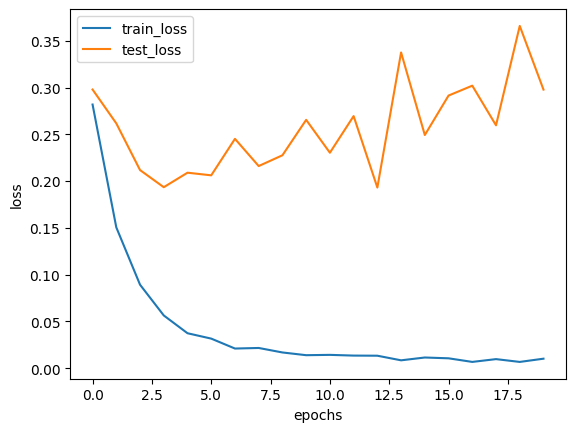

In [72]:
plt.plot(range(num_epochs), history["train_loss"], label="train_loss")
plt.plot(range(num_epochs), history["test_loss"], label="test_loss")
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend();

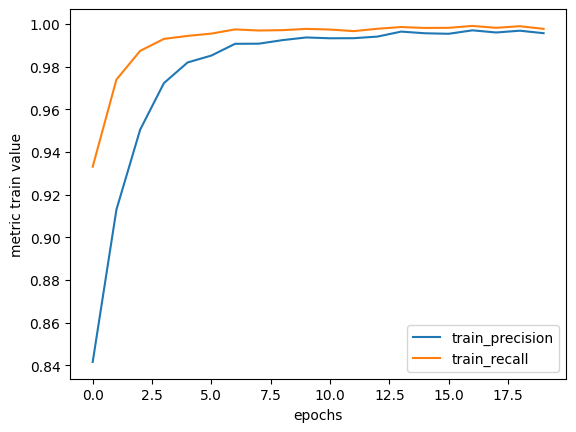

In [73]:
plt.plot(range(num_epochs), history["train_precision"], label="train_precision")
plt.plot(range(num_epochs), history["train_recall"], label="train_recall")
plt.xlabel('epochs')
plt.ylabel('metric train value')
plt.legend();

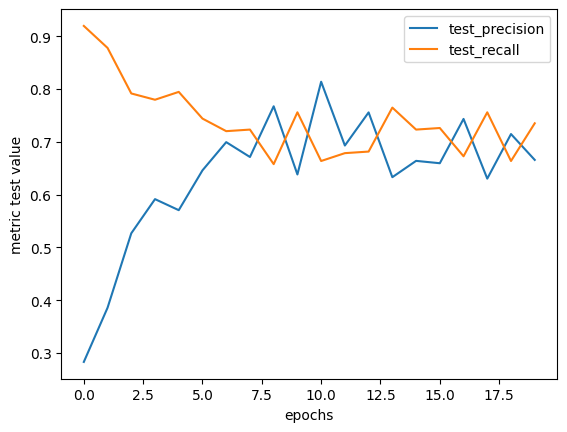

In [74]:
plt.plot(range(num_epochs), history["test_precision"], label="test_precision")
plt.plot(range(num_epochs), history["test_recall"], label="test_recall")
plt.xlabel('epochs')
plt.ylabel('metric test value')
plt.legend();

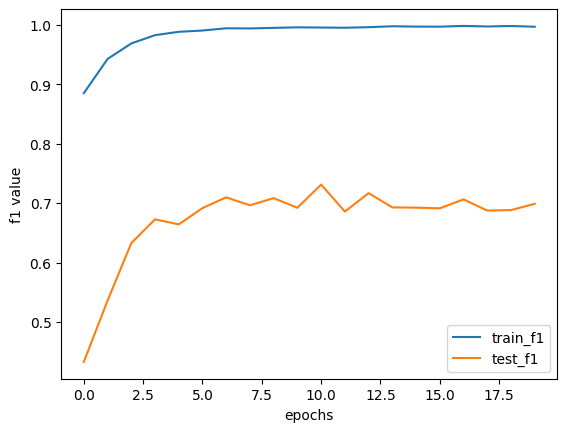

In [75]:
plt.plot(range(num_epochs), history["train_f1"], label="train_f1")
plt.plot(range(num_epochs), history["test_f1"], label="test_f1")
plt.xlabel('epochs')
plt.ylabel('f1 value')
plt.legend();

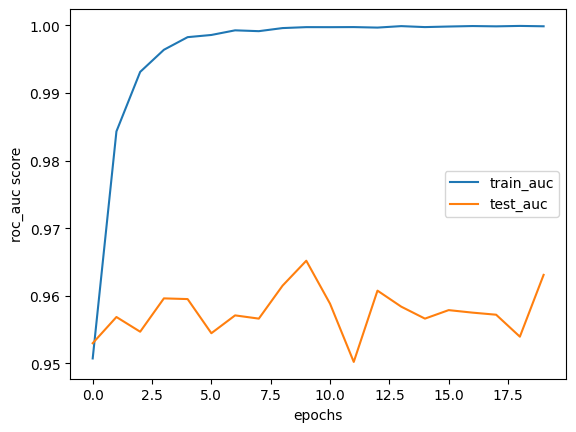

In [76]:
plt.plot(range(num_epochs), history["train_auc"], label="train_auc")
plt.plot(range(num_epochs), history["test_auc"], label="test_auc")
plt.xlabel('epochs')
plt.ylabel('roc_auc score')
plt.legend();

## Классические baseline-модели
Чтобы понять, оправдана ли нейросетевая сложность, сравниваю GRU-подход с простым `TF-IDF + MultinomialNB` и oversampling-стратегиями.


In [ ]:
try:
    from imblearn.over_sampling import ADASYN, SMOTE
    from imblearn.pipeline import Pipeline
except ImportError as exc:
    raise ImportError(
        "Install `imbalanced-learn` to run the classical baselines."
    ) from exc

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

In [35]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from imblearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.metrics import classification_report

## TF-IDF + SMOTE + MultinomialNB


In [36]:
X_train, X_test, y_train, y_test = train_test_split(texts, labels,
                                                    test_size=0.15,
                                                    stratify=labels,
                                                    random_state=1)

In [37]:
textclassifier = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000)),
    ('smote', SMOTE(random_state=1)),
    ('mnb', MultinomialNB(alpha=0.1))
])

In [38]:
textclassifier.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [39]:
pred = textclassifier.predict(X_test)

In [40]:
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
auc = roc_auc_score(y_test, pred)
smote_result = {
    'Precision': precision,
    'Recall': recall,
    'F1': f1,
    'ROC_AUC': auc
}

smote_result

{'Precision': 0.5184466019417475,
 'Recall': 0.7946428571428571,
 'F1': 0.627497062279671,
 'ROC_AUC': 0.8695062648208678}

## TF-IDF + ADASYN + MultinomialNB


In [41]:
textclassifier = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000)),
    ('smote', ADASYN(random_state=1)),
    ('mnb', MultinomialNB(alpha=0.1))
])

In [42]:
textclassifier.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [43]:
pred = textclassifier.predict(X_test)

In [44]:
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
auc = roc_auc_score(y_test, pred)
adasyn_result = {
    'Precision': precision,
    'Recall': recall,
    'F1': f1,
    'ROC_AUC': auc
}

adasyn_result

{'Precision': 0.4800693240901213,
 'Recall': 0.8244047619047619,
 'F1': 0.6067907995618839,
 'ROC_AUC': 0.8785550054476703}

## Эксперимент с Focal Loss


Идея этого блока проста: наказывать ошибки на сложных и редких объектах сильнее, чем на лёгких. Это естественная гипотеза для бинарной классификации с выраженным дисбалансом.


In [45]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        if self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


In [46]:
embed_dim = token_model.config.hidden_size
hidden_size = 256
output_size = 1

model = BertRNN(embed_dim, hidden_size).to(device)
token_model = token_model.to(device)
loss_fn = FocalLoss(alpha=4.0, gamma=2.0)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)

In [ ]:
torch.manual_seed(1)
num_epochs = 10

history_fl = {
    "train_loss": [],
    "test_loss": [],
    "train_precision": [],
    "test_precision": [],
    "train_recall": [],
    "test_recall": [],
    "train_f1": [],
    "test_f1": [],
    "train_auc": [],
    "test_auc": [],
}

print(f"{'Epoch':>5} | {'tr_loss':>8} | {'tst_loss':>8} || "
      f"{'tr_prec':>8} | {'tst_prec':>8} || "
      f"{'tr_recl':>8} | {'tst_recl':>8} || "
      f"{'tr_f1':>8} | {'tst_f1':>8} || "
      f"{'tr_auc':>8} | {'tst_auc':>8}")

print("-" * 120)

for epoch in range(num_epochs):
    train_loss, train_precision, train_recall, train_f1, train_auc = train_fn(train_dl, epoch)
    test_loss, test_precision, test_recall, test_f1, test_auc = test_fn(test_dl, epoch)

    history_fl["train_loss"].append(train_loss)
    history_fl["test_loss"].append(test_loss)
    history_fl["train_precision"].append(train_precision)
    history_fl["test_precision"].append(test_precision)
    history_fl["train_recall"].append(train_recall)
    history_fl["test_recall"].append(test_recall)
    history_fl["train_f1"].append(train_f1)
    history_fl["test_f1"].append(test_f1)
    history_fl["train_auc"].append(train_auc)
    history_fl["test_auc"].append(test_auc)

    print(f"{epoch+1:5d} | "
          f"{train_loss:8.4f} | {test_loss:8.4f} || "
          f"{train_precision:8.3f} | {test_precision:8.3f} || "
          f"{train_recall:8.3f} | {test_recall:8.3f} || "
          f"{train_f1:8.3f} | {test_f1:8.3f} || "
          f"{train_auc:8.3f} | {test_auc:8.3f}")

## Финальный вывод

Этот проект лучше всего показывает разницу между подходами для imbalanced text classification, а не попытку выжать максимум из одной модели.

По сохранённым результатам:
- `DistilBERT embeddings + GRU` дал лучший hold-out `f1` около `0.69` при `ROC-AUC` около `0.94`;
- `TF-IDF + SMOTE + MultinomialNB` остаётся сильным и дешёвым baseline с `f1 около 0.63`;
- `ADASYN` в этой задаче не улучшил качество относительно SMOTE;
- `Focal Loss` не дал стабильного выигрыша по сравнению с `BCEWithLogitsLoss`.

Переобучение видно на графиках: train-метрики быстро уходят к 1.0, тогда как hold-out стабилизируется заметно ниже.

Что можно было бы улучшить:
- добавить отдельную validation-выборку и подбирать порог классификации на ней;
- усилить регуляризацию (`dropout`, `weight decay`) или уменьшить размер GRU-головы;
- попробовать fine-tuning трансформера с ранней остановкой и `class weights`.


In [98]:
comparison = pd.DataFrame(
    [
        {
            "model": "DistilBERT embeddings + GRU",
            "precision": history['test_precision'][-1],
            "recall": history['test_recall'][-1],
            "f1": history['test_f1'][-1],
            "roc_auc": history['test_auc'][-1],
        },
        {
            "model": "DistilBERT embeddings + GRU + FocalLoss",
            "precision": history_fl['test_precision'][-1],
            "recall": history_fl['test_recall'][-1],
            "f1": history_fl['test_f1'][-1],
            "roc_auc": history_fl['test_auc'][-1],
        },
        {
            "model": "TF-IDF + SMOTE + MultinomialNB",
            "precision": smote_result['Precision'],
            "recall": smote_result['Recall'],
            "f1": smote_result['F1'],
            "roc_auc": smote_result['ROC_AUC'],
        },
        {
            "model": "TF-IDF + ADASYN + MultinomialNB",
            "precision": adasyn_result['Precision'],
            "recall": adasyn_result['Recall'],
            "f1": adasyn_result['F1'],
            "roc_auc": adasyn_result['ROC_AUC'],
        },
    ]
)
comparison.sort_values("f1", ascending=False)

,model,precision,recall,f1,roc_auc
1,DistilBERT embeddings + GRU + FocalLoss,0.780576,0.645833,0.706840,0.955350
0,DistilBERT embeddings + GRU,0.665768,0.735119,0.698727,0.963083
2,TF-IDF + SMOTE + MultinomialNB,0.518447,0.794643,0.627497,0.869506
3,TF-IDF + ADASYN + MultinomialNB,0.480069,0.824405,0.606791,0.878555
